<a href="https://colab.research.google.com/github/MohammadAburub93/Python-Data-Science-Practice/blob/main/Nobel%20Prize%20Analysis/Nobel_Prize_Analysis_(start).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup and Context

### Introduction

On November 27, 1895, Alfred Nobel signed his last will in Paris. When it was opened after his death, the will caused a lot of controversy, as Nobel had left much of his wealth for the establishment of a prize.

Alfred Nobel dictates that his entire remaining estate should be used to endow “prizes to those who, during the preceding year, have conferred the greatest benefit to humankind”.

Every year the Nobel Prize is given to scientists and scholars in the categories chemistry, literature, physics, physiology or medicine, economics, and peace.

<img src=https://i.imgur.com/36pCx5Q.jpg>

Let's see what patterns we can find in the data of the past Nobel laureates. What can we learn about the Nobel prize and our world more generally?

In [287]:
#%pip install --upgrade plotly

### Import Statements

In [288]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

### Notebook Presentation

In [289]:
pd.options.display.float_format = '{:,.2f}'.format

### Read the Data

In [290]:
df_data = pd.read_csv('nobel_prize_data.csv')

# Data Exploration & Cleaning


In [291]:
df_data.shape

(962, 16)

In [292]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 962 entries, 0 to 961
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   year                   962 non-null    int64 
 1   category               962 non-null    object
 2   prize                  962 non-null    object
 3   motivation             874 non-null    object
 4   prize_share            962 non-null    object
 5   laureate_type          962 non-null    object
 6   full_name              962 non-null    object
 7   birth_date             934 non-null    object
 8   birth_city             931 non-null    object
 9   birth_country          934 non-null    object
 10  birth_country_current  934 non-null    object
 11  sex                    934 non-null    object
 12  organization_name      707 non-null    object
 13  organization_city      707 non-null    object
 14  organization_country   708 non-null    object
 15  ISO                    

In [293]:
df_data.head()

,year,category,prize,motivation,prize_share,laureate_type,full_name,birth_date,birth_city,birth_country,birth_country_current,sex,organization_name,organization_city,organization_country,ISO
0,1901,Chemistry,The Nobel Prize in Chemistry 1901,"""in recognition of the extraordinary services ...",1/1,Individual,Jacobus Henricus van 't Hoff,1852-08-30,Rotterdam,Netherlands,Netherlands,Male,Berlin University,Berlin,Germany,NLD
1,1901,Literature,The Nobel Prize in Literature 1901,"""in special recognition of his poetic composit...",1/1,Individual,Sully Prudhomme,1839-03-16,Paris,France,France,Male,NaN,NaN,NaN,FRA
2,1901,Medicine,The Nobel Prize in Physiology or Medicine 1901,"""for his work on serum therapy, especially its...",1/1,Individual,Emil Adolf von Behring,1854-03-15,Hansdorf (Lawice),Prussia (Poland),Poland,Male,Marburg University,Marburg,Germany,POL
3,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,Individual,Frédéric Passy,1822-05-20,Paris,France,France,Male,NaN,NaN,NaN,FRA
4,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,Individual,Jean Henry Dunant,1828-05-08,Geneva,Switzerland,Switzerland,Male,NaN,NaN,NaN,CHE


In [294]:
df_data.tail()

,year,category,prize,motivation,prize_share,laureate_type,full_name,birth_date,birth_city,birth_country,birth_country_current,sex,organization_name,organization_city,organization_country,ISO
957,2020,Medicine,The Nobel Prize in Physiology or Medicine 2020,“for the discovery of Hepatitis C virus”,1/3,Individual,Michael Houghton,1949-07-02,NaN,United Kingdom,United Kingdom,Male,University of Alberta,Edmonton,Canada,GBR
958,2020,Peace,The Nobel Peace Prize 2020,"“for its efforts to combat hunger, for its con...",1/1,Organization,World Food Programme (WFP),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
959,2020,Physics,The Nobel Prize in Physics 2020,“for the discovery of a supermassive compact o...,1/4,Individual,Andrea Ghez,1965-06-16,"New York, NY",United States of America,United States of America,Female,University of California,"Berkeley, CA",United States of America,USA
960,2020,Physics,The Nobel Prize in Physics 2020,“for the discovery of a supermassive compact o...,1/4,Individual,Reinhard Genzel,1952-03-24,Bad Homburg vor der Höhe,Germany,Germany,Male,University of California,"Los Angeles, CA",United States of America,DEU
961,2020,Physics,The Nobel Prize in Physics 2020,“for the discovery that black hole formation i...,1/2,Individual,Roger Penrose,1931-08-08,Colchester,United Kingdom,United Kingdom,Male,University of Oxford,Oxford,United Kingdom,GBR


### Check for Duplicates

In [295]:
df_data.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
957,False
958,False
959,False
960,False


In [296]:
df_data.duplicated().sum()

np.int64(0)

### Check for NaN Values

In [297]:
df_data.isna()

,year,category,prize,motivation,prize_share,laureate_type,full_name,birth_date,birth_city,birth_country,birth_country_current,sex,organization_name,organization_city,organization_country,ISO
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,True,False,False,False,False,False,False,False,False,True,True,True,False
4,False,False,False,True,False,False,False,False,False,False,False,False,True,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
957,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
958,False,False,False,False,False,False,False,True,True,True,True,True,True,True,True,True
959,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
960,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [298]:
df_data.isna().values.any()

np.True_

In [299]:
df_data.isna().sum()

,0
year,0
category,0
prize,0
motivation,88
prize_share,0
laureate_type,0
full_name,0
birth_date,28
birth_city,31
birth_country,28


In [300]:
col_subset = ['year','category', 'laureate_type',
              'birth_date','full_name', 'organization_name']
df_data.loc[df_data.birth_date.isna()][col_subset]

,year,category,laureate_type,birth_date,full_name,organization_name
24,1904,Peace,Organization,NaN,Institut de droit international (Institute of ...,NaN
60,1910,Peace,Organization,NaN,Bureau international permanent de la Paix (Per...,NaN
89,1917,Peace,Organization,NaN,Comité international de la Croix Rouge (Intern...,NaN
200,1938,Peace,Organization,NaN,Office international Nansen pour les Réfugiés ...,NaN
215,1944,Peace,Organization,NaN,Comité international de la Croix Rouge (Intern...,NaN
237,1947,Peace,Organization,NaN,American Friends Service Committee (The Quakers),NaN
238,1947,Peace,Organization,NaN,Friends Service Council (The Quakers),NaN
283,1954,Peace,Organization,NaN,Office of the United Nations High Commissioner...,NaN
348,1963,Peace,Organization,NaN,Comité international de la Croix Rouge (Intern...,NaN
349,1963,Peace,Organization,NaN,Ligue des Sociétés de la Croix-Rouge (League o...,NaN


In [301]:
col_subset = ['year','category', 'laureate_type',
              'birth_date','full_name', 'organization_name']
df_data.loc[df_data.organization_name.isna()][col_subset]

,year,category,laureate_type,birth_date,full_name,organization_name
1,1901,Literature,Individual,1839-03-16,Sully Prudhomme,NaN
3,1901,Peace,Individual,1822-05-20,Frédéric Passy,NaN
4,1901,Peace,Individual,1828-05-08,Jean Henry Dunant,NaN
7,1902,Literature,Individual,1817-11-30,Christian Matthias Theodor Mommsen,NaN
9,1902,Peace,Individual,1843-05-21,Charles Albert Gobat,NaN
...,...,...,...,...,...,...
932,2018,Peace,Individual,1993-07-02,Nadia Murad,NaN
942,2019,Literature,Individual,1942-12-06,Peter Handke,NaN
946,2019,Peace,Individual,1976-08-15,Abiy Ahmed Ali,NaN
954,2020,Literature,Individual,1943-04-22,Louise Glück,NaN


### Type Conversions



#### Convert Year and Birth Date to Datetime

In [302]:
df_data.birth_date = pd.to_datetime(df_data.birth_date)

In [303]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 962 entries, 0 to 961
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   year                   962 non-null    int64         
 1   category               962 non-null    object        
 2   prize                  962 non-null    object        
 3   motivation             874 non-null    object        
 4   prize_share            962 non-null    object        
 5   laureate_type          962 non-null    object        
 6   full_name              962 non-null    object        
 7   birth_date             934 non-null    datetime64[ns]
 8   birth_city             931 non-null    object        
 9   birth_country          934 non-null    object        
 10  birth_country_current  934 non-null    object        
 11  sex                    934 non-null    object        
 12  organization_name      707 non-null    object        
 13  organ

#### Add a Column with the Prize Share as a Percentage

In [304]:
separated_value = df_data.prize_share.str.split('/', expand=True)
print(separated_value)
numerator = pd.to_numeric(separated_value[0])
denomenator = pd.to_numeric(separated_value[1])
df_data['share_pct'] = numerator / denomenator
df_data.head()

     0  1
0    1  1
1    1  1
2    1  1
3    1  2
4    1  2
..  .. ..
957  1  3
958  1  1
959  1  4
960  1  4
961  1  2

[962 rows x 2 columns]


,year,category,prize,motivation,prize_share,laureate_type,full_name,birth_date,birth_city,birth_country,birth_country_current,sex,organization_name,organization_city,organization_country,ISO,share_pct
0,1901,Chemistry,The Nobel Prize in Chemistry 1901,"""in recognition of the extraordinary services ...",1/1,Individual,Jacobus Henricus van 't Hoff,1852-08-30,Rotterdam,Netherlands,Netherlands,Male,Berlin University,Berlin,Germany,NLD,1.00
1,1901,Literature,The Nobel Prize in Literature 1901,"""in special recognition of his poetic composit...",1/1,Individual,Sully Prudhomme,1839-03-16,Paris,France,France,Male,NaN,NaN,NaN,FRA,1.00
2,1901,Medicine,The Nobel Prize in Physiology or Medicine 1901,"""for his work on serum therapy, especially its...",1/1,Individual,Emil Adolf von Behring,1854-03-15,Hansdorf (Lawice),Prussia (Poland),Poland,Male,Marburg University,Marburg,Germany,POL,1.00
3,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,Individual,Frédéric Passy,1822-05-20,Paris,France,France,Male,NaN,NaN,NaN,FRA,0.50
4,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,Individual,Jean Henry Dunant,1828-05-08,Geneva,Switzerland,Switzerland,Male,NaN,NaN,NaN,CHE,0.50


In [305]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 962 entries, 0 to 961
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   year                   962 non-null    int64         
 1   category               962 non-null    object        
 2   prize                  962 non-null    object        
 3   motivation             874 non-null    object        
 4   prize_share            962 non-null    object        
 5   laureate_type          962 non-null    object        
 6   full_name              962 non-null    object        
 7   birth_date             934 non-null    datetime64[ns]
 8   birth_city             931 non-null    object        
 9   birth_country          934 non-null    object        
 10  birth_country_current  934 non-null    object        
 11  sex                    934 non-null    object        
 12  organization_name      707 non-null    object        
 13  organ

# Plotly Donut Chart: Percentage of Male vs. Female Laureates

In [306]:
gender_data = df_data.sex.value_counts()
fig = px.pie(labels=gender_data.index,
             values=gender_data.values,
             names=gender_data.index,
             hole=0.5)
fig.update_traces(textposition='inside', textfont_size=14, textinfo='percent')
fig.show()

# Who were the first 3 Women to Win the Nobel Prize?



In [307]:
df_data[df_data.sex == 'Female'].sort_values('year').head(3)

,year,category,prize,motivation,prize_share,laureate_type,full_name,birth_date,birth_city,birth_country,birth_country_current,sex,organization_name,organization_city,organization_country,ISO,share_pct
18,1903,Physics,The Nobel Prize in Physics 1903,"""in recognition of the extraordinary services ...",1/4,Individual,"Marie Curie, née Sklodowska",1867-11-07,Warsaw,Russian Empire (Poland),Poland,Female,NaN,NaN,NaN,POL,0.25
29,1905,Peace,The Nobel Peace Prize 1905,NaN,1/1,Individual,"Baroness Bertha Sophie Felicita von Suttner, n...",1843-06-09,Prague,Austrian Empire (Czech Republic),Czech Republic,Female,NaN,NaN,NaN,CZE,1.00
51,1909,Literature,The Nobel Prize in Literature 1909,"""in appreciation of the lofty idealism, vivid ...",1/1,Individual,Selma Ottilia Lovisa Lagerlöf,1858-11-20,Mårbacka,Sweden,Sweden,Female,NaN,NaN,NaN,SWE,1.00


# Find the Repeat Winners


In [308]:
repeat_win = df_data.duplicated(subset=['full_name'], keep=False)

In [309]:
repeat_win_set = df_data[repeat_win]
print(f'There are {repeat_win_set.full_name.nunique()} winners who where win more than one price')

There are 6 winners who where win more than one price


In [310]:
col_subset = ['year', 'category', 'laureate_type', 'full_name']
repeat_win_set[col_subset]

,year,category,laureate_type,full_name
18,1903,Physics,Individual,"Marie Curie, née Sklodowska"
62,1911,Chemistry,Individual,"Marie Curie, née Sklodowska"
89,1917,Peace,Organization,Comité international de la Croix Rouge (Intern...
215,1944,Peace,Organization,Comité international de la Croix Rouge (Intern...
278,1954,Chemistry,Individual,Linus Carl Pauling
283,1954,Peace,Organization,Office of the United Nations High Commissioner...
297,1956,Physics,Individual,John Bardeen
306,1958,Chemistry,Individual,Frederick Sanger
340,1962,Peace,Individual,Linus Carl Pauling
348,1963,Peace,Organization,Comité international de la Croix Rouge (Intern...


In [311]:
df_data.category.nunique()

6

In [312]:
prize_per_category = df_data.category.value_counts()

In [313]:
bar = px.bar(x=prize_per_category.index,
             y=prize_per_category.values,
             color=prize_per_category.values,
             color_continuous_scale='Aggrnyl',
             title='Number of Prices Awarded per Category')

bar.update_layout(
    xaxis_title='Prize Category',
    yaxis_title='Number of Prizes',
    coloraxis_showscale=False)

bar.show()

In [314]:
df_data[df_data.category == 'Economics'].head()

,year,category,prize,motivation,prize_share,laureate_type,full_name,birth_date,birth_city,birth_country,birth_country_current,sex,organization_name,organization_city,organization_country,ISO,share_pct
393,1969,Economics,The Sveriges Riksbank Prize in Economic Scienc...,"""for having developed and applied dynamic mode...",1/2,Individual,Jan Tinbergen,1903-04-12,the Hague,Netherlands,Netherlands,Male,The Netherlands School of Economics,Rotterdam,Netherlands,NLD,0.50
394,1969,Economics,The Sveriges Riksbank Prize in Economic Scienc...,"""for having developed and applied dynamic mode...",1/2,Individual,Ragnar Frisch,1895-03-03,Oslo,Norway,Norway,Male,University of Oslo,Oslo,Norway,NOR,0.50
402,1970,Economics,The Sveriges Riksbank Prize in Economic Scienc...,"""for the scientific work through which he has ...",1/1,Individual,Paul A. Samuelson,1915-05-15,"Gary, IN",United States of America,United States of America,Male,Massachusetts Institute of Technology (MIT),"Cambridge, MA",United States of America,USA,1.00
411,1971,Economics,The Sveriges Riksbank Prize in Economic Scienc...,"""for his empirically founded interpretation of...",1/1,Individual,Simon Kuznets,1901-04-30,Pinsk,Russian Empire (Belarus),Belarus,Male,Harvard University,"Cambridge, MA",United States of America,BLR,1.00
419,1972,Economics,The Sveriges Riksbank Prize in Economic Scienc...,"""for their pioneering contributions to general...",1/2,Individual,John R. Hicks,1904-04-08,Warwick,United Kingdom,United Kingdom,Male,University of Oxford,Oxford,United Kingdom,GBR,0.50


In [315]:
df_data[df_data.category == 'Economics'].iloc[0]

,393
year,1969
category,Economics
prize,The Sveriges Riksbank Prize in Economic Scienc...
motivation,"""for having developed and applied dynamic mode..."
prize_share,1/2
laureate_type,Individual
full_name,Jan Tinbergen
birth_date,1903-04-12 00:00:00
birth_city,the Hague
birth_country,Netherlands


# Male and Female Winners by Category



In [316]:
cat_gend = df_data.groupby(['category', 'sex'], as_index=False).agg({'prize': pd.Series.count})

In [317]:
cat_gend.sort_values('prize',ascending=False, inplace=True)

In [318]:
cat_gen_bar = px.bar(cat_gend,
                     x='category',
                     y='prize',
                     color='sex',
                     title='Number of Prizes Awarded by Category Split by Men & Women')

cat_gen_bar.update_layout(
    xaxis_title='Prize Category',
    yaxis_title='Number of Prizes',
)
cat_gen_bar.show()

# Number of Prizes Awarded Over Time




In [319]:
prize_year = df_data.groupby('year').agg({'prize':pd.Series.count})

In [320]:
roll_p_y = prize_year.rolling(window=5).mean()

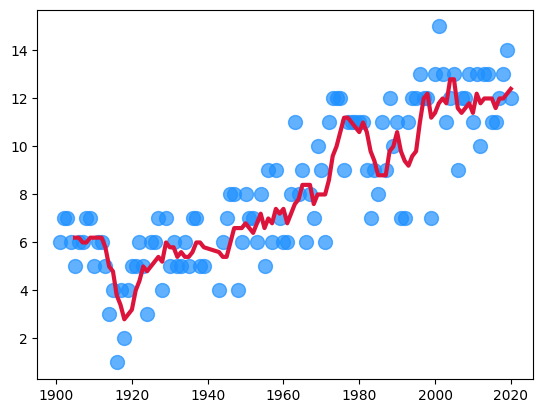

In [321]:
plt.scatter(prize_year.index,
            prize_year.values,
            color='dodgerblue',
            alpha=0.7,
            s=100)
plt.plot(prize_year.index,
         roll_p_y.values,
         color='crimson',
         linewidth=3)
plt.show()

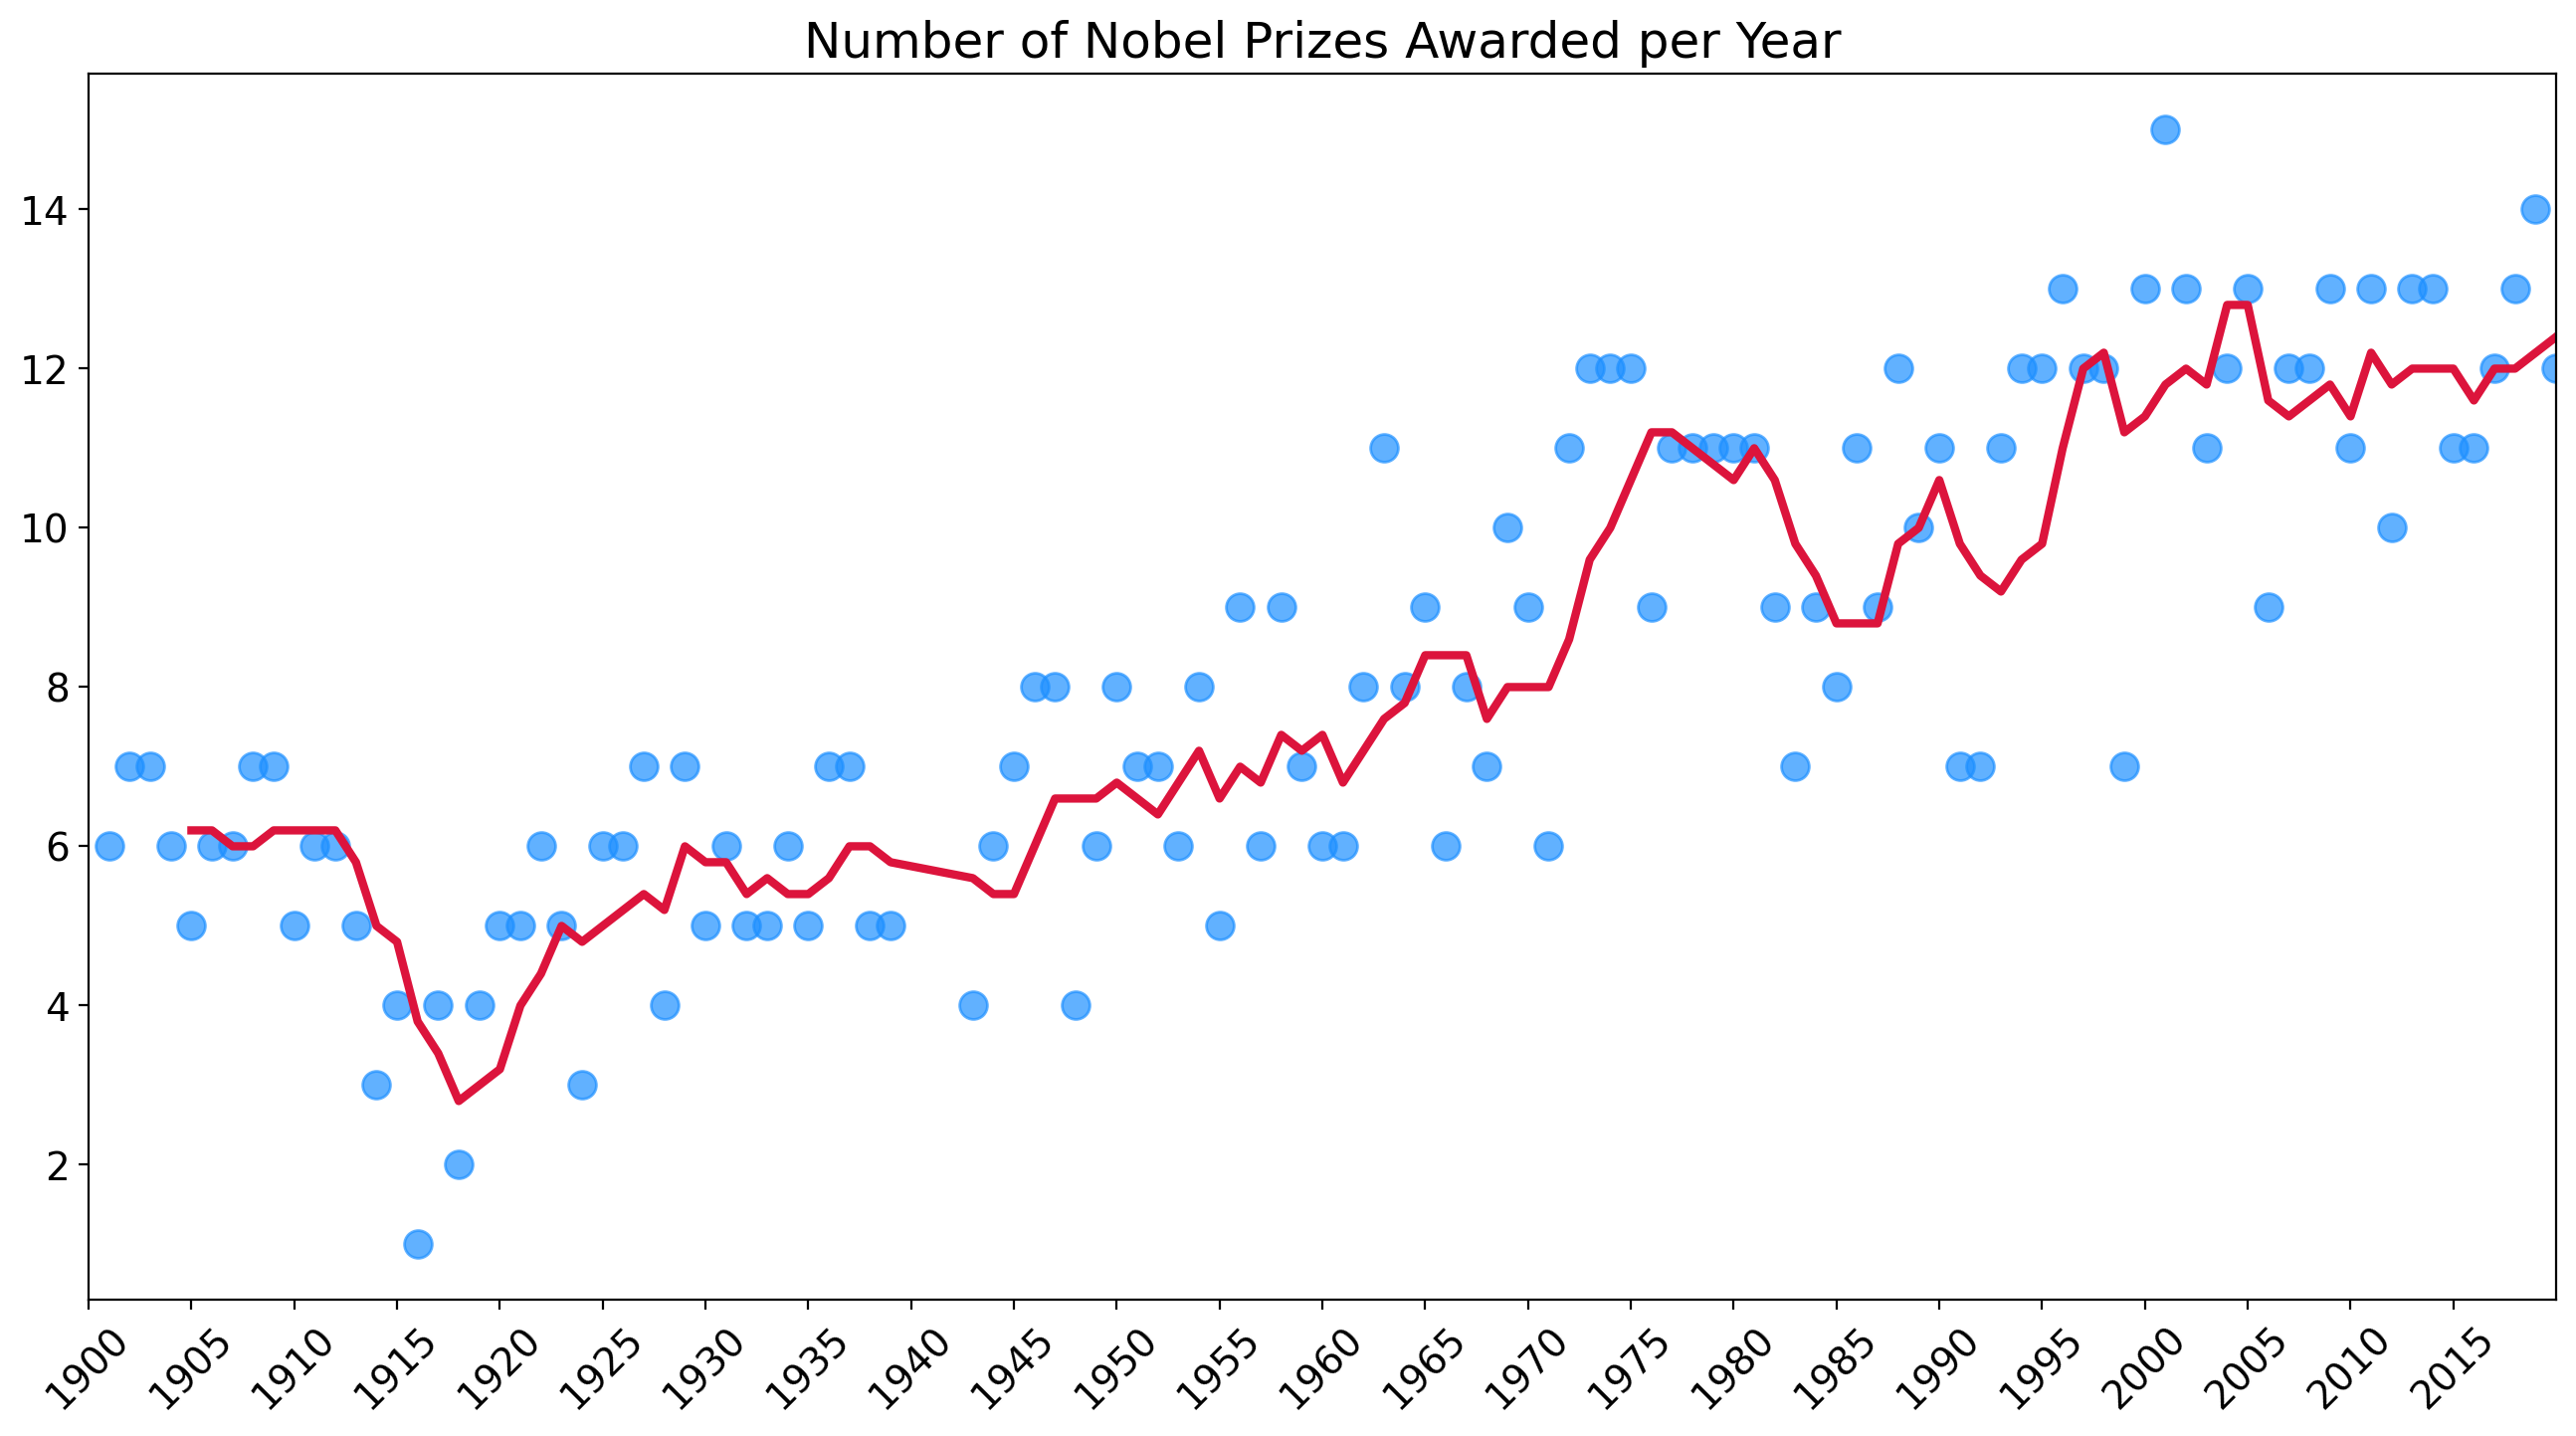

In [322]:
plt.figure(figsize=(16,8), dpi=200)
plt.title('Number of Nobel Prizes Awarded per Year', fontsize=18)
plt.yticks(fontsize=14)
plt.xticks(ticks= np.arange(1900, 2020, step=5),
           fontsize=14,
           rotation=45)

ax = plt.gca()
ax.set_xlim(1900,2020)

ax.scatter(prize_year.index,
            prize_year.values,
            color='dodgerblue',
            alpha=0.7,
            s=100)
ax.plot(prize_year.index,
         roll_p_y.values,
         color='crimson',
         linewidth=3)
plt.show()

# Are More Prizes Shared Than Before?



In [323]:
share_avg = df_data.groupby(by='year').agg({'share_pct': pd.Series.mean})

In [324]:
roll_share_avg = share_avg.rolling(window=5).mean()

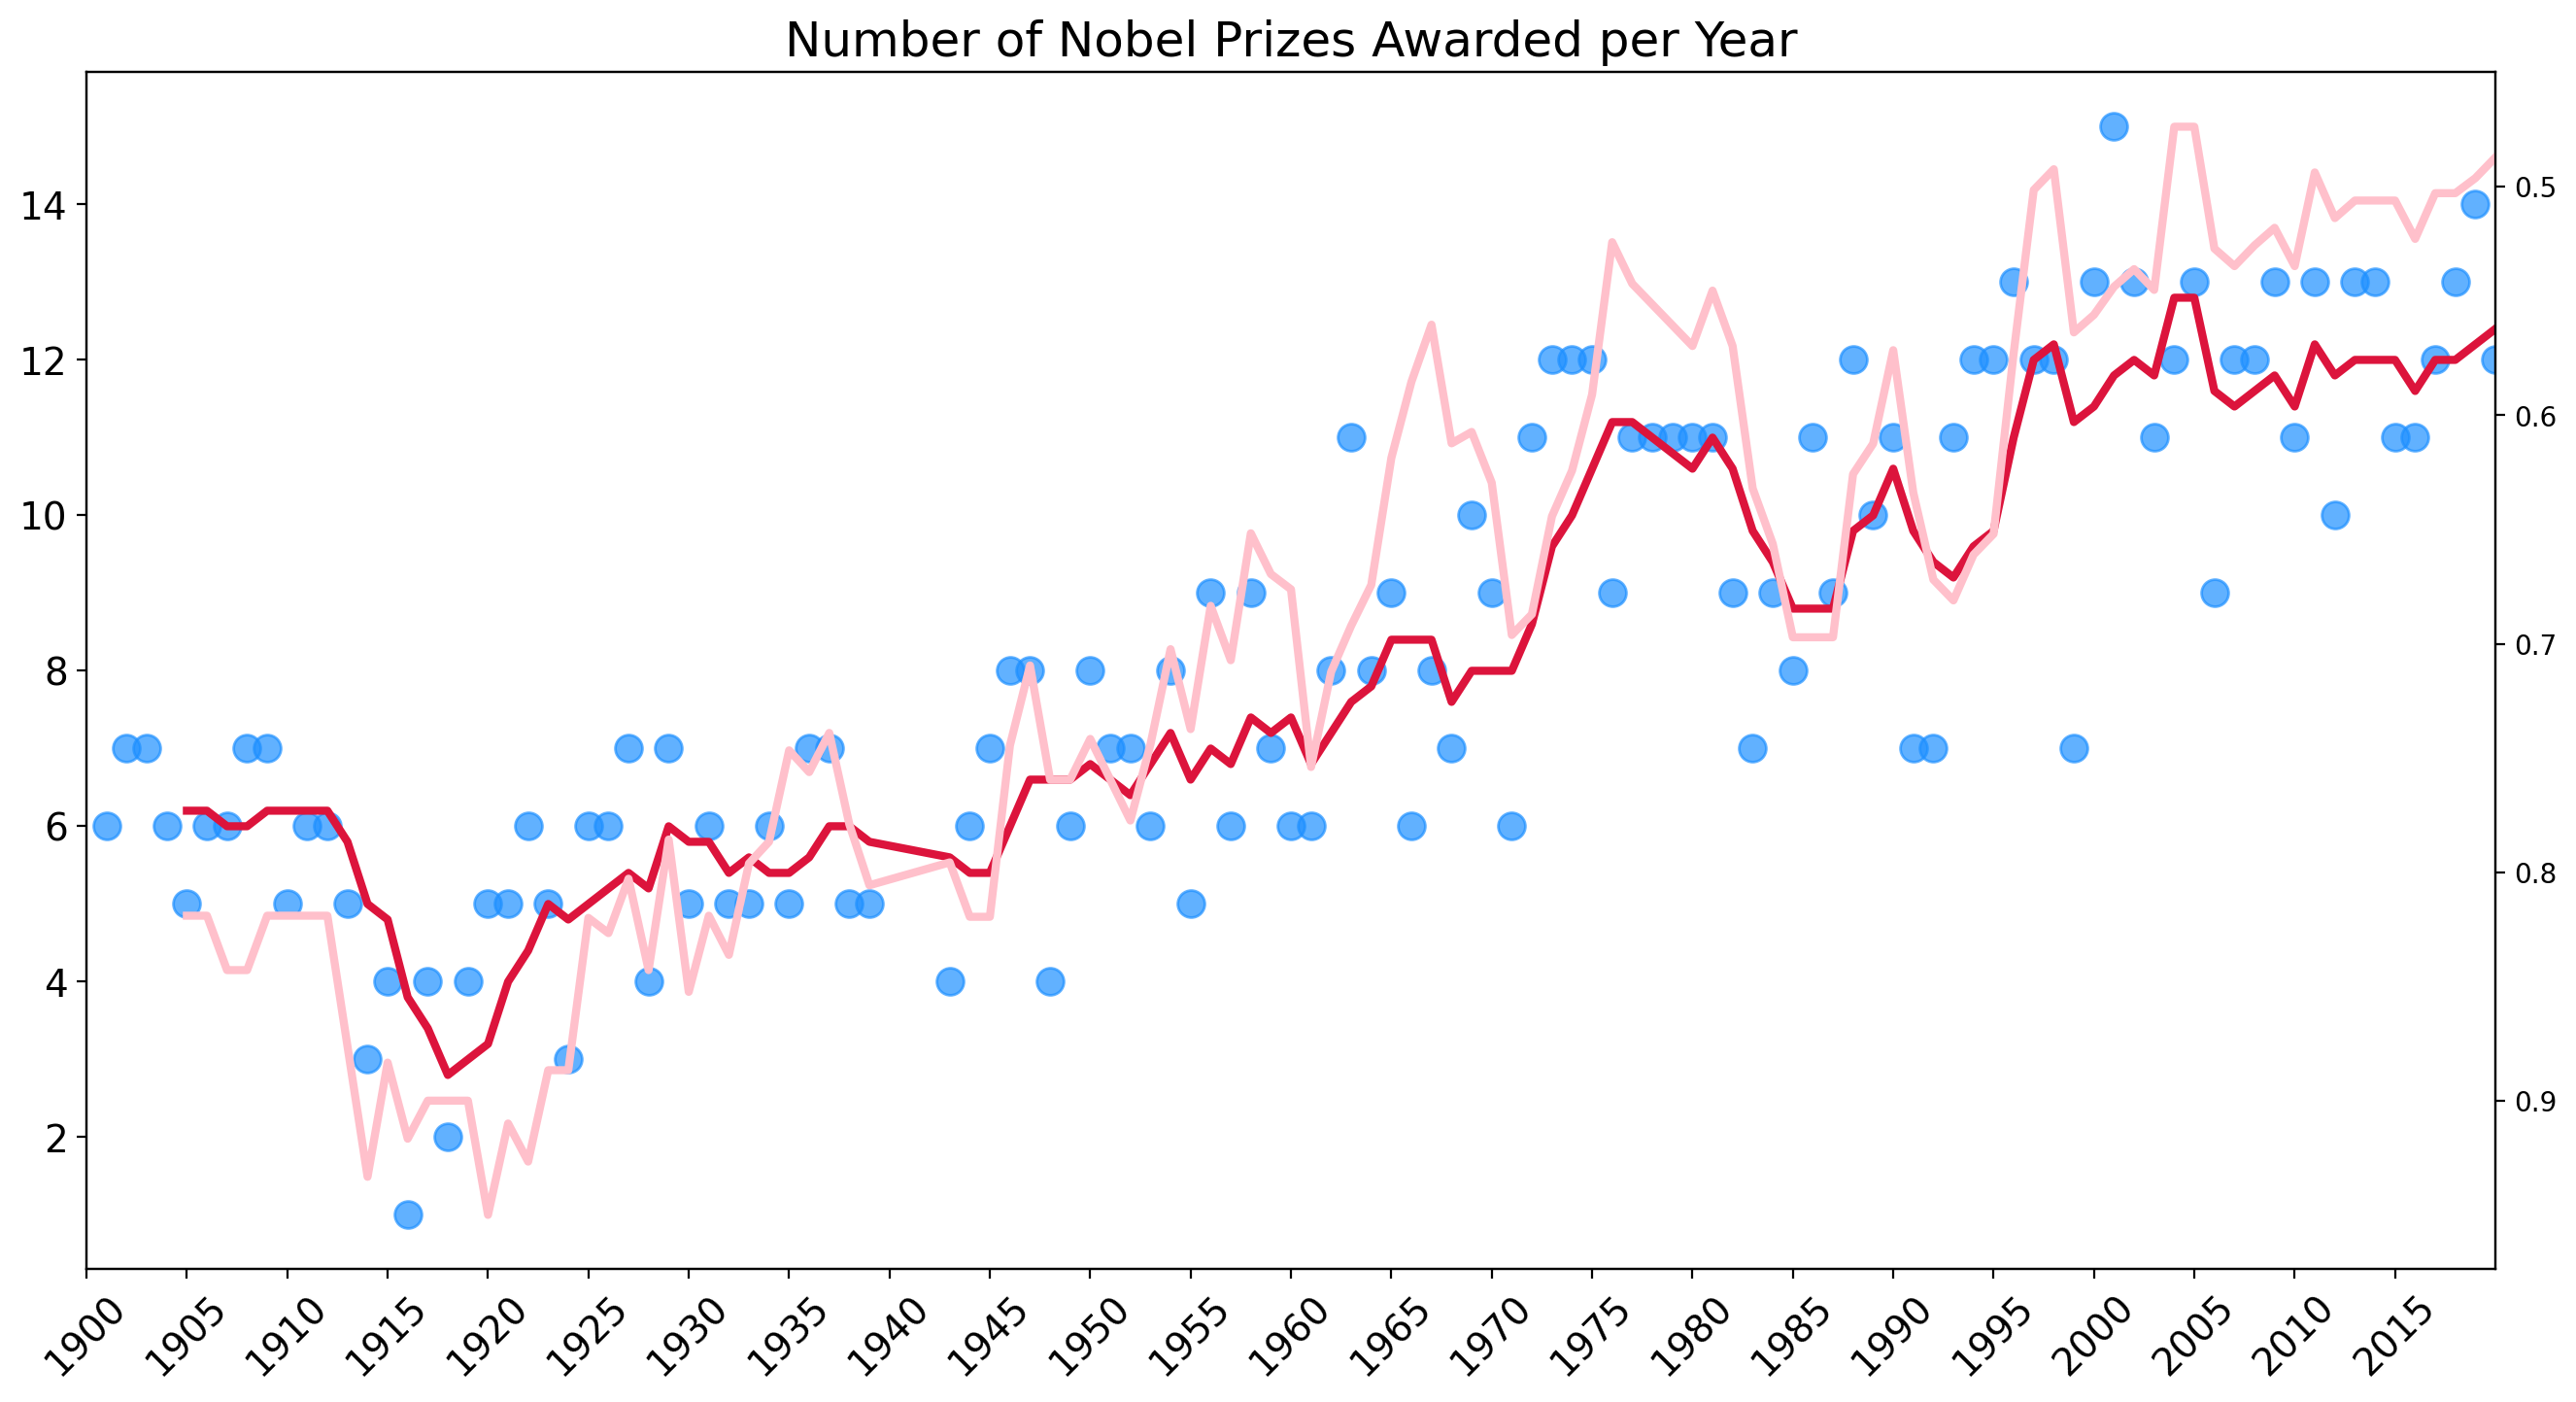

In [325]:
plt.figure(figsize=(16,8), dpi=200)
plt.title('Number of Nobel Prizes Awarded per Year', fontsize=18)
plt.yticks(fontsize=14)
plt.xticks(ticks= np.arange(1900, 2020, step=5),
           fontsize=14,
           rotation=45)

ax1 = plt.gca()
ax2= ax1.twinx()
ax1.set_xlim(1900,2020)

ax1.scatter(prize_year.index,
            prize_year.values,
            color='dodgerblue',
            alpha=0.7,
            s=100)
ax1.plot(prize_year.index,
         roll_p_y.values,
         color='crimson',
         linewidth=3)
ax2.plot(share_avg.index,
         roll_share_avg.values,
         color='pink',
         linewidth=3)
ax2.invert_yaxis()
plt.show()

# The Countries with the Most Nobel Prizes

In [326]:
top_countries = df_data.groupby(by='birth_country_current', as_index=False).agg({'prize':pd.Series.count})

In [327]:
top_countries.sort_values('prize', inplace=True)

In [328]:
top20_countries = top_countries[-20:]

In [329]:
top20_countries

,birth_country_current,prize
33,India,9
31,Hungary,9
65,South Africa,9
2,Australia,10
20,Denmark,12
13,China,12
54,Norway,12
3,Austria,18
51,Netherlands,18
39,Italy,19


In [330]:
fig = px.bar(top20_countries,
       y='birth_country_current',
       x='prize', orientation='h',
       color='prize')

fig.update_layout(
    title='Top 20 Countries by Number of prizes',
    xaxis_title='Number of Prizes',
    yaxis_title='Countrey',
    coloraxis_showscale=False
)

fig.show()

# Use a Choropleth Map to Show the Number of Prizes Won by Country



In [331]:
countries_iso = df_data.groupby(by=['birth_country_current', 'ISO'], as_index=False).agg({'prize':pd.Series.count})

In [332]:
px.choropleth(countries_iso, locations='ISO', color='prize', color_continuous_scale='matter')

# In Which Categories are the Different Countries Winning Prizes?



In [333]:
cat_prize = df_data.groupby(by=['birth_country_current', 'category'], as_index=False).agg({'prize':pd.Series.count})

In [334]:
cat_prize.sort_values('prize',ascending=False, inplace=True)

In [335]:
cat_prize

,birth_country_current,category,prize
204,United States of America,Medicine,78
206,United States of America,Physics,70
201,United States of America,Chemistry,55
202,United States of America,Economics,49
198,United Kingdom,Medicine,28
...,...,...,...
190,Turkey,Chemistry,1
207,Venezuela,Medicine,1
208,Vietnam,Peace,1
209,Yemen,Peace,1


In [336]:
merged_df = pd.merge(cat_prize, top20_countries, on='birth_country_current')

In [337]:
merged_df.columns = ['birth_country_current', 'category', 'cat_prize', 'total_prize']

In [338]:
merged_df.sort_values('total_prize', inplace=True)

In [339]:
merged_df

,birth_country_current,category,cat_prize,total_prize
61,South Africa,Medicine,3,9
55,Hungary,Chemistry,3,9
58,South Africa,Peace,3,9
81,Hungary,Medicine,2,9
105,Hungary,Economics,1,9
...,...,...,...,...
3,United States of America,Economics,49,281
2,United States of America,Chemistry,55,281
9,United States of America,Peace,19,281
0,United States of America,Medicine,78,281


In [340]:
cat_gen_bar = px.bar(merged_df,
                     x='cat_prize',
                     y='birth_country_current',
                     color='category',
                     title='Top 20 Countries by Number of Prizes & Category',
                     orientation='h')

cat_gen_bar.update_layout(
    xaxis_title='Number of Prizes',
    yaxis_title='Countery',
)
cat_gen_bar.show()

### Number of Prizes Won by Each Country Over Time



In [341]:
year_cont_prize = df_data.groupby(by=['year', 'birth_country_current'], as_index=False).agg({'prize': pd.Series.count})

In [342]:
year_cont_prize.head()

,year,birth_country_current,prize
0,1901,France,2
1,1901,Germany,1
2,1901,Netherlands,1
3,1901,Poland,1
4,1901,Switzerland,1


In [343]:
year_cont_prize['Cumulative_Value_Year'] = year_cont_prize.groupby('birth_country_current')['prize'].cumsum()

In [344]:
year_cont_prize.head()

,year,birth_country_current,prize,Cumulative_Value_Year
0,1901,France,2,2
1,1901,Germany,1,1
2,1901,Netherlands,1,1
3,1901,Poland,1,1
4,1901,Switzerland,1,1


In [345]:
l_chart = px.line(year_cont_prize,
                  x='year',
                  y='Cumulative_Value_Year',
                  color='birth_country_current',
                  hover_name='birth_country_current')
l_chart.update_layout(xaxis_title='Year',
                      yaxis_title='Number of Prizes')
l_chart.show()

# What are the Top Research Organisations?



In [346]:
org_prize = df_data.groupby('organization_name', as_index=False)['prize'].count()

In [347]:
org_prize.sort_values('prize', inplace=True)

In [348]:
org_prize

,organization_name,prize
255,Western Reserve University,1
0,A.F. Ioffe Physico-Technical Institute,1
253,Weizmann Institute of Science,1
263,École municipale de physique et de chimie indu...,1
251,Walter and Eliza Hall Institute for Medical Re...,1
...,...,...
198,University of Chicago,20
117,Massachusetts Institute of Technology (MIT),21
167,Stanford University,23
68,Harvard University,29


In [349]:
top20_org = org_prize[-20:]

In [350]:
org_bar = px.bar(top20_org,
       x='prize',
       y='organization_name',
      color='prize',
       orientation='h',
       title='Top 20 Organization per Awarded Prizes',
        color_continuous_scale='viridis')

org_bar.update_layout(
    xaxis_title='Number of Prizes',
    yaxis_title='Institution',
    coloraxis_showscale=False
)

org_bar.show()

# Which Cities Make the Most Discoveries?



In [351]:
df_data.head()

,year,category,prize,motivation,prize_share,laureate_type,full_name,birth_date,birth_city,birth_country,birth_country_current,sex,organization_name,organization_city,organization_country,ISO,share_pct
0,1901,Chemistry,The Nobel Prize in Chemistry 1901,"""in recognition of the extraordinary services ...",1/1,Individual,Jacobus Henricus van 't Hoff,1852-08-30,Rotterdam,Netherlands,Netherlands,Male,Berlin University,Berlin,Germany,NLD,1.00
1,1901,Literature,The Nobel Prize in Literature 1901,"""in special recognition of his poetic composit...",1/1,Individual,Sully Prudhomme,1839-03-16,Paris,France,France,Male,NaN,NaN,NaN,FRA,1.00
2,1901,Medicine,The Nobel Prize in Physiology or Medicine 1901,"""for his work on serum therapy, especially its...",1/1,Individual,Emil Adolf von Behring,1854-03-15,Hansdorf (Lawice),Prussia (Poland),Poland,Male,Marburg University,Marburg,Germany,POL,1.00
3,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,Individual,Frédéric Passy,1822-05-20,Paris,France,France,Male,NaN,NaN,NaN,FRA,0.50
4,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,Individual,Jean Henry Dunant,1828-05-08,Geneva,Switzerland,Switzerland,Male,NaN,NaN,NaN,CHE,0.50


In [352]:
city_prize = df_data.groupby('organization_city', as_index=False)['prize'].count()

In [353]:
city_prize.sort_values('prize', inplace=True)

In [354]:
top20_city = city_prize[-20:]

In [355]:
city_bar = px.bar(top20_city,
       x='prize',
       y='organization_city',
      color='prize',
       orientation='h',
       title='Top 20 Cities per Awarded Prizes',
        color_continuous_scale='viridis')

city_bar.update_layout(
    xaxis_title='Number of Prizes',
    yaxis_title='City Name',
    coloraxis_showscale=False)

city_bar.show()

# Where are Nobel Laureates Born? Chart the Laureate Birth Cities




In [356]:
birth_city_prize = df_data.groupby('birth_city', as_index=False)['prize'].count()

In [357]:
birth_city_prize.sort_values('prize', inplace=True)

In [358]:
birth_city_prize

,birth_city,prize
413,Oslo,1
401,Nyeri,1
402,Næstved,1
404,"Oakland, CA",1
405,"Oceanside, NY",1
...,...,...
112,"Chicago, IL",12
572,Vienna,14
313,London,19
418,Paris,26


In [359]:
top20_birth_city = birth_city_prize[-20:]

In [360]:
birth_city_bar = px.bar(top20_birth_city,
       x='prize',
       y='birth_city',
      color='prize',
       orientation='h',
       title='Top 20 Cities per Awarded Prizes',
        color_continuous_scale='Plasma')

birth_city_bar.update_layout(
    xaxis_title='Number of Prizes',
    yaxis_title='City Name',
    coloraxis_showscale=False)

birth_city_bar.show()

# Plotly Sunburst Chart: Combine Country, City, and Organisation





In [361]:
org_cont_prize = df_data.groupby(['organization_name', 'organization_city', 'organization_country'], as_index=False)['prize'].count()

In [362]:
org_cont_prize.head()

,organization_name,organization_city,organization_country,prize
0,A.F. Ioffe Physico-Technical Institute,St. Petersburg,Russia,1
1,Aarhus University,Aarhus,Denmark,1
2,Academy of Sciences,Moscow,Russia,3
3,Amsterdam University,Amsterdam,Netherlands,2
4,Argonne National Laboratory,"Argonne, IL",United States of America,1


In [363]:
sun_fig = px.sunburst(org_cont_prize,
                      path=['organization_country', 'organization_city', 'organization_name'], values='prize')
sun_fig.show()

# Patterns in the Laureate Age at the Time of the Award




In [364]:
df_data['winning_age'] = df_data.year - df_data.birth_date.dt.year

In [365]:
df_data.tail()

,year,category,prize,motivation,prize_share,laureate_type,full_name,birth_date,birth_city,birth_country,birth_country_current,sex,organization_name,organization_city,organization_country,ISO,share_pct,winning_age
957,2020,Medicine,The Nobel Prize in Physiology or Medicine 2020,“for the discovery of Hepatitis C virus”,1/3,Individual,Michael Houghton,1949-07-02,NaN,United Kingdom,United Kingdom,Male,University of Alberta,Edmonton,Canada,GBR,0.33,71.00
958,2020,Peace,The Nobel Peace Prize 2020,"“for its efforts to combat hunger, for its con...",1/1,Organization,World Food Programme (WFP),NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00,NaN
959,2020,Physics,The Nobel Prize in Physics 2020,“for the discovery of a supermassive compact o...,1/4,Individual,Andrea Ghez,1965-06-16,"New York, NY",United States of America,United States of America,Female,University of California,"Berkeley, CA",United States of America,USA,0.25,55.00
960,2020,Physics,The Nobel Prize in Physics 2020,“for the discovery of a supermassive compact o...,1/4,Individual,Reinhard Genzel,1952-03-24,Bad Homburg vor der Höhe,Germany,Germany,Male,University of California,"Los Angeles, CA",United States of America,DEU,0.25,68.00
961,2020,Physics,The Nobel Prize in Physics 2020,“for the discovery that black hole formation i...,1/2,Individual,Roger Penrose,1931-08-08,Colchester,United Kingdom,United Kingdom,Male,University of Oxford,Oxford,United Kingdom,GBR,0.50,89.00


### Who were the oldest and youngest winners?


In [366]:
df_data.describe()

,year,birth_date,share_pct,winning_age
count,962.00,934,962.00,934.00
mean,"1,971.82",1912-03-28 22:50:37.259100672,0.63,59.95
min,"1,901.00",1817-11-30 00:00:00,0.25,17.00
25%,"1,948.00",1892-04-06 00:00:00,0.33,51.00
50%,"1,977.00",1917-10-30 12:00:00,0.50,60.00
75%,"2,001.00",1937-04-24 18:00:00,1.00,69.00
max,"2,020.00",1997-07-12 00:00:00,1.00,97.00
std,33.81,NaN,0.29,12.62


In [367]:
df_data.iloc[[df_data.winning_age.idxmax()]]

,year,category,prize,motivation,prize_share,laureate_type,full_name,birth_date,birth_city,birth_country,birth_country_current,sex,organization_name,organization_city,organization_country,ISO,share_pct,winning_age
937,2019,Chemistry,The Nobel Prize in Chemistry 2019,“for the development of lithium-ion batteries”,1/3,Individual,John Goodenough,1922-07-25,Jena,Germany,Germany,Male,University of Texas,Austin TX,United States of America,DEU,0.33,97.00


In [368]:
df_data.iloc[[df_data.winning_age.idxmin()]]

,year,category,prize,motivation,prize_share,laureate_type,full_name,birth_date,birth_city,birth_country,birth_country_current,sex,organization_name,organization_city,organization_country,ISO,share_pct,winning_age
885,2014,Peace,The Nobel Peace Prize 2014,"""for their struggle against the suppression of...",1/2,Individual,Malala Yousafzai,1997-07-12,Mingora,Pakistan,Pakistan,Female,NaN,NaN,NaN,PAK,0.50,17.00


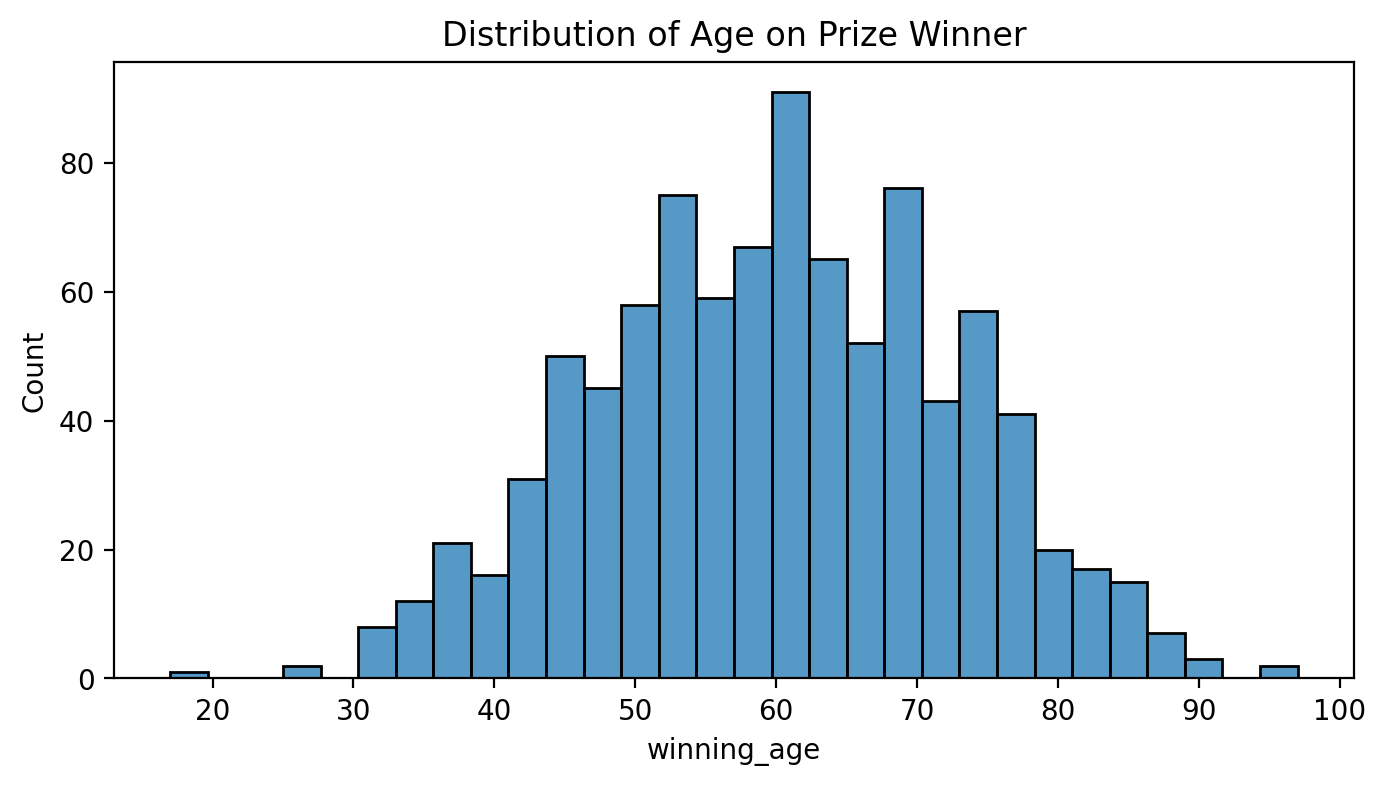

In [370]:
plt.figure(figsize=(8,4), dpi=200)
plt.title('Distribution of Age on Prize Winner')

sns.histplot(df_data, x='winning_age',
             bins=30)
plt.show()

### Age at Time of Award throughout History




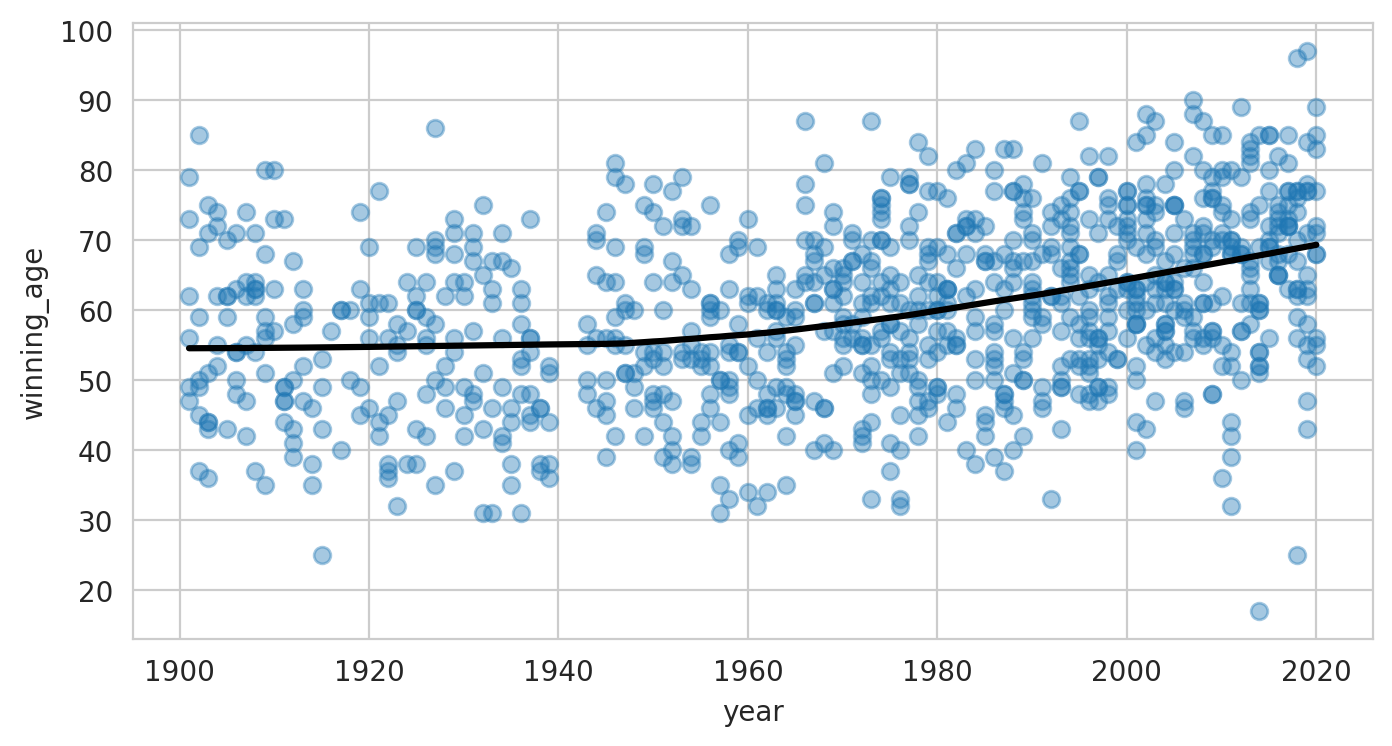

In [372]:
plt.figure(figsize=(8,4), dpi=200)
with sns.axes_style('whitegrid'):
  sns.regplot(df_data,
              x='year',
              y='winning_age',
              lowess=True,
              scatter_kws={'alpha': 0.4},
              line_kws={'color':'black'})

  plt.show()

### Winning Age Across the Nobel Prize Categories



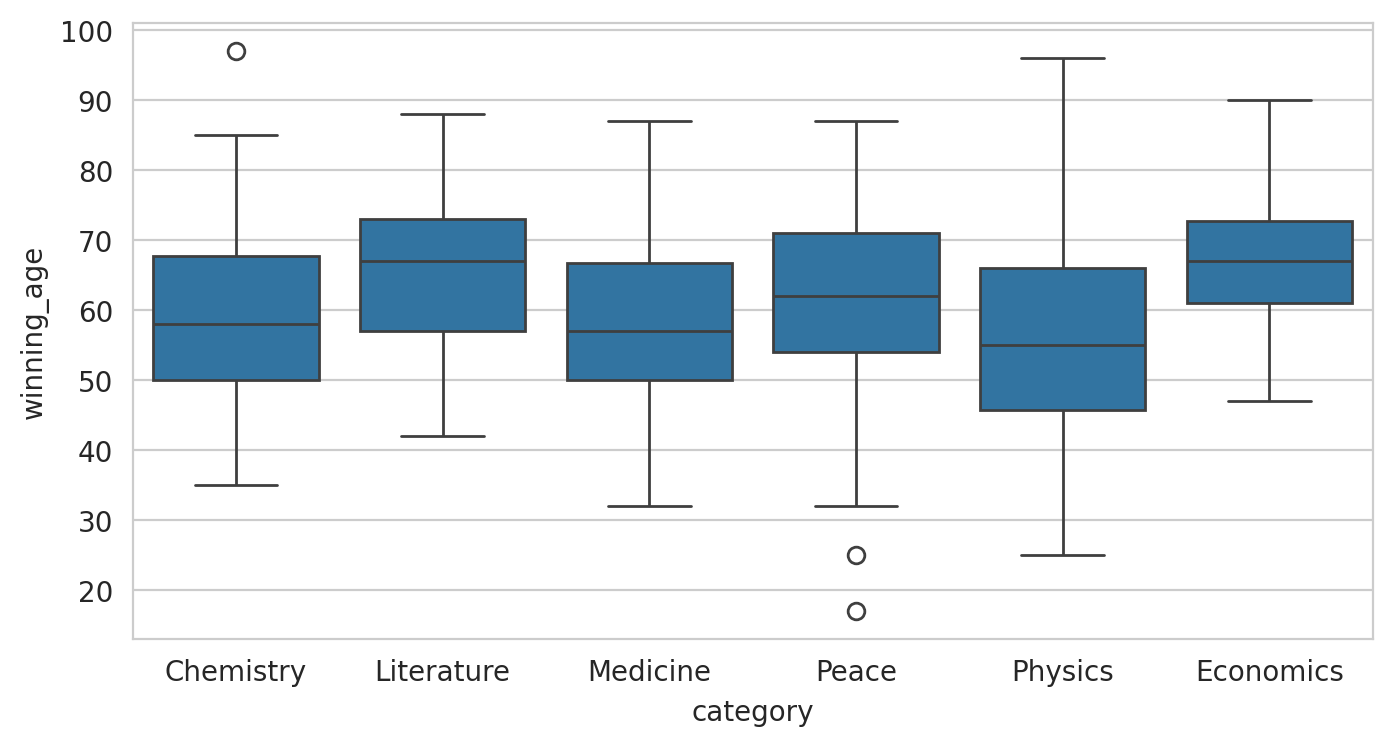

In [376]:
plt.figure(figsize=(8,4), dpi=200)
with sns.axes_style('whitegrid'):
  sns.boxplot(df_data, x='category', y='winning_age')
plt.show()

<Figure size 1600x800 with 0 Axes>

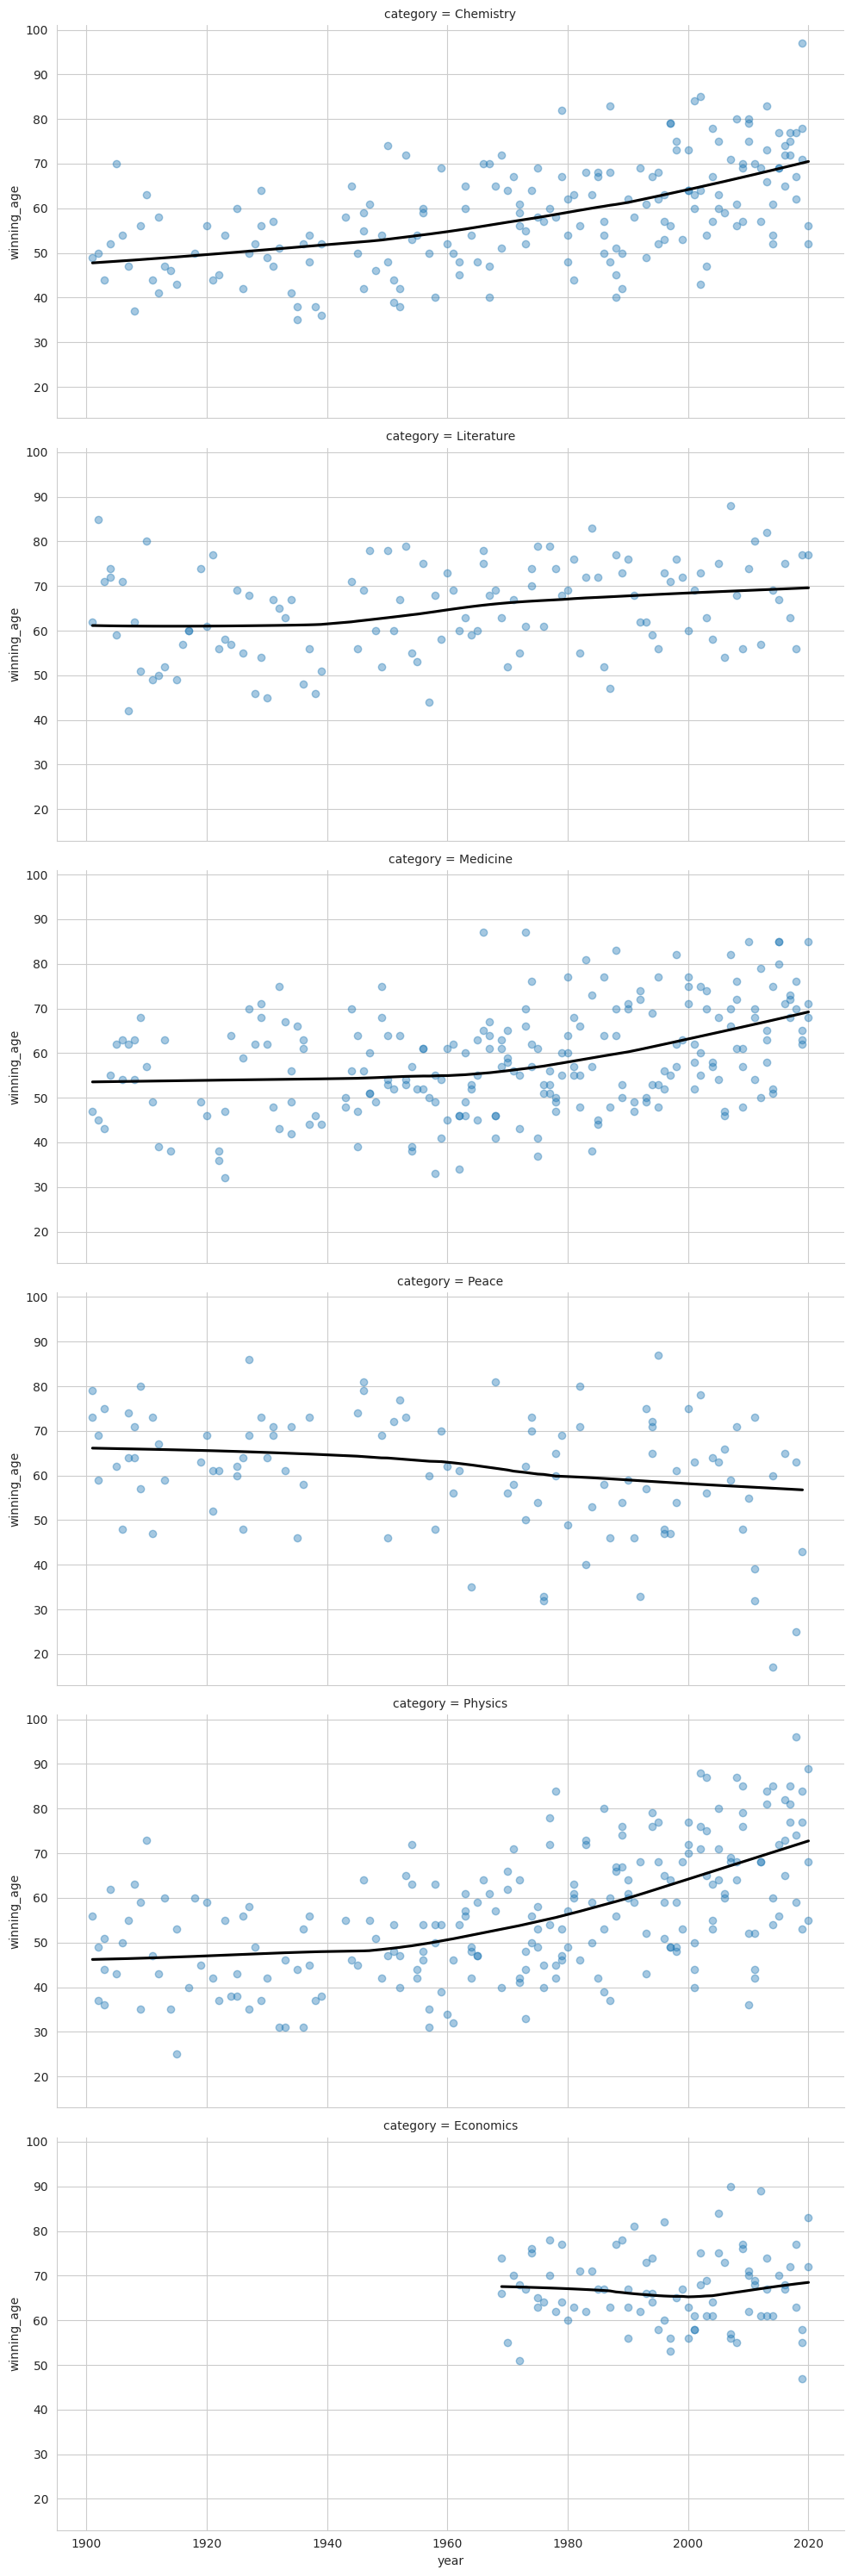

In [382]:
plt.figure(figsize=(8,4), dpi=200)
with sns.axes_style('whitegrid'):
  sns.lmplot(df_data,
             x='year',
             y='winning_age',
             row='category',
             lowess=True,
             scatter_kws={'alpha': 0.4},
            line_kws={'color':'black'},
             aspect=2)
plt.show()

<Figure size 1600x800 with 0 Axes>

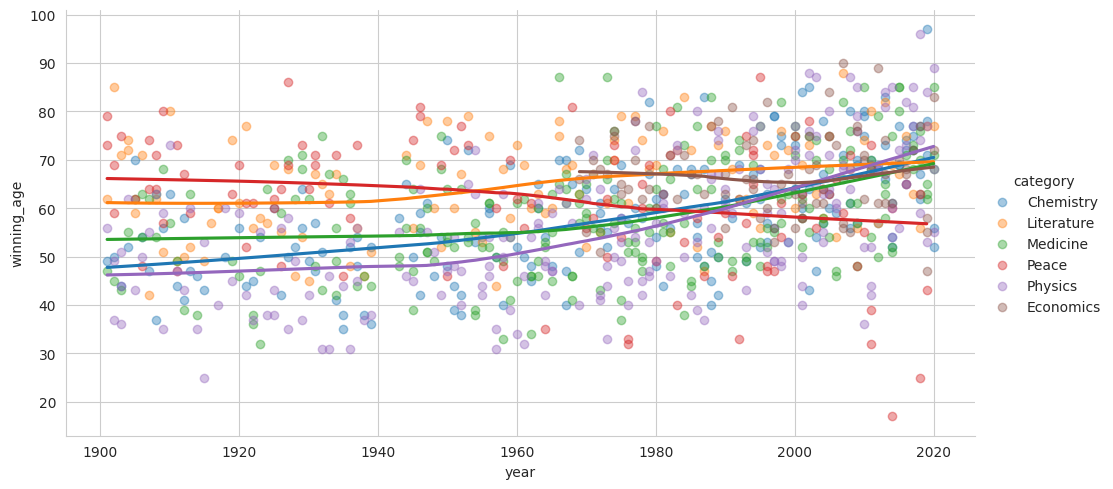

In [385]:
plt.figure(figsize=(8,4), dpi=200)
with sns.axes_style('whitegrid'):
  sns.lmplot(df_data,
             x='year',
             y='winning_age',
             hue='category',
             lowess=True,
             scatter_kws={'alpha': 0.4},
             aspect=2)
plt.show()